In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting data and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# The 6 classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

# Used to time how long each model takes to train
import time

# Display settings so we can see full tables
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load transaction file
transactions = pd.read_csv(r"D:\fauzan\MSc Data Analytics\Dissertation\HI-Medium_Trans.csv")

# Load account file
accounts = pd.read_csv(r"D:\fauzan\MSc Data Analytics\Dissertation\HI-Medium_accounts.csv")

print("Transaction Dataset Shape:")
print(transactions.shape)

print("Account Dataset Shape:")
print(accounts.shape)

print("Columns in HI-Medium_Trans.csv:")
print(transactions.columns.tolist())

print("Columns in HI-Medium_Accounts.csv:")
print(accounts.columns.tolist())

Transaction Dataset Shape:
(31898238, 11)
Account Dataset Shape:
(2087786, 5)
Columns in HI-Medium_Trans.csv:
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
Columns in HI-Medium_Accounts.csv:
['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']


In [3]:
print("First 5 rows of Transaction Dataset:")
print(transactions.head())

print("First 5 rows of Account Dataset:")
print(accounts.head())

First 5 rows of Transaction Dataset:
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:17         20  800104D70       20  800104D70   
1  2022/09/01 00:02       3196  800107150     3196  800107150   
2  2022/09/01 00:17       1208  80010E430     1208  80010E430   
3  2022/09/01 00:03       1208  80010E650       20  80010E6F0   
4  2022/09/01 00:02       1208  80010E650       20  80010EA30   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          6794.63          US Dollar      6794.63        US Dollar   
1          7739.29          US Dollar      7739.29        US Dollar   
2          1880.23          US Dollar      1880.23        US Dollar   
3      73966883.00          US Dollar  73966883.00        US Dollar   
4      45868454.00          US Dollar  45868454.00        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1   Reinvestment              0  
2   Reinvestment              0  
3        

In [4]:
print("Transaction Dataset Info:")
print(transactions.info())

print("Account Dataset Info:")
print(accounts.info())

Transaction Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31898238 entries, 0 to 31898237
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 2.6+ GB
None
Account Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087786 entries, 0 to 2087785
Data columns (total 5 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   Bank Name       object
 1   Bank ID         int64 
 2   Account Number  object
 3   Entity ID       object
 4   Entity Name     object
dtypes: int64(1), object(4)
memor

In [5]:
print(transactions['Is Laundering'].value_counts())
print(transactions['Is Laundering'].value_counts(normalize=True) * 100)

Is Laundering
0    31863008
1       35230
Name: count, dtype: int64
Is Laundering
0    99.889555
1     0.110445
Name: proportion, dtype: float64


In [6]:
#Taking a random sample, keeping the same ratio of laundering vs non-laundering transactions
# frac=0.07 takes about 7% of the data, which gives roughly 2,230,000 rows which is easily manageable for a normal PC
sample_df = (
    transactions.groupby('Is Laundering', group_keys=False)
    .sample(frac=0.07, random_state=42)
    .reset_index(drop=True)
)

print("Sampled transaction shape:", sample_df.shape)
print("Class balance after sampling:")
print(sample_df['Is Laundering'].value_counts())

Sampled transaction shape: (2232877, 11)
Class balance after sampling:
Is Laundering
0    2230411
1       2466
Name: count, dtype: int64


In [7]:
# Build a matching key for sender and receiver accounts
# The accounts file identifies an account using Bank ID + Account Number together
# So we build the SAME combined key in the transaction file to match sender and receiver accounts

sample_df['Sender_Key'] = sample_df['From Bank'].astype(str) + '_' + sample_df['Account'].astype(str)
sample_df['Receiver_Key'] = sample_df['To Bank'].astype(str) + '_' + sample_df['Account.1'].astype(str)
accounts['Acc_Key'] = accounts['Bank ID'].astype(str) + '_' + accounts['Account Number'].astype(str)

print("Keys created successfully. Example:")
print(sample_df[['From Bank', 'Account', 'Sender_Key']].head())

Keys created successfully. Example:
   From Bank    Account         Sender_Key
0      29574  8053A7450    29574_8053A7450
1    2142469  8341DC7F0  2142469_8341DC7F0
2    1145753  835CA35C0  1145753_835CA35C0
3     218456  8087AF690   218456_8087AF690
4       9340  80F9C4840     9340_80F9C4840


In [8]:
# Merge sender (From) account information
sample_df = sample_df.merge(
    accounts[['Acc_Key', 'Entity Name']].rename(columns={'Entity Name': 'Sender_Entity_Type'}),
    left_on='Sender_Key', right_on='Acc_Key', how='left'
)
sample_df = sample_df.drop(columns=['Acc_Key'])

# Merge receiver (To) account information
sample_df = sample_df.merge(
    accounts[['Acc_Key', 'Entity Name']].rename(columns={'Entity Name': 'Receiver_Entity_Type'}),
    left_on='Receiver_Key', right_on='Acc_Key', how='left'
)
sample_df = sample_df.drop(columns=['Acc_Key'])

print("Merged dataset shape:", sample_df.shape)
print(sample_df[['Sender_Entity_Type', 'Receiver_Entity_Type']].head(10))

Merged dataset shape: (2232877, 15)
            Sender_Entity_Type         Receiver_Entity_Type
0           Partnership #11135           Partnership #20893
1          Partnership #129763          Corporation #130199
2          Partnership #129969  Sole Proprietorship #131587
3           Corporation #66013          Corporation #201649
4   Sole Proprietorship #21369   Sole Proprietorship #33670
5          Partnership #167416  Sole Proprietorship #165757
6  Sole Proprietorship #110780          Partnership #174477
7  Sole Proprietorship #104945  Sole Proprietorship #106105
8   Sole Proprietorship #18805          Partnership #201646
9           Partnership #74983           Corporation #80313


In [9]:
# Clean up the Entity Type text
# The original values look like "Corporation #183669" — we only need the TYPE, not the unique number
sample_df['Sender_Entity_Type'] = sample_df['Sender_Entity_Type'].astype(str).str.extract(r'([A-Za-z ]+)')[0].str.strip()
sample_df['Receiver_Entity_Type'] = sample_df['Receiver_Entity_Type'].astype(str).str.extract(r'([A-Za-z ]+)')[0].str.strip()

print("Unique sender entity types:", sample_df['Sender_Entity_Type'].unique())
print("Unique receiver entity types:", sample_df['Receiver_Entity_Type'].unique())

Unique sender entity types: ['Partnership' 'Corporation' 'Sole Proprietorship' 'Country' 'Individual'
 'Direct']
Unique receiver entity types: ['Partnership' 'Corporation' 'Sole Proprietorship' 'Country' 'Individual'
 'Direct']


In [10]:
print("Missing values in each column:")
print(sample_df.isnull().sum())

# Fill any missing entity types with the label "Unknown" rather than deleting rows
sample_df['Sender_Entity_Type'] = sample_df['Sender_Entity_Type'].fillna('Unknown')
sample_df['Receiver_Entity_Type'] = sample_df['Receiver_Entity_Type'].fillna('Unknown')

print("\nMissing values after fixing:")
print(sample_df.isnull().sum())

Missing values in each column:
Timestamp               0
From Bank               0
Account                 0
To Bank                 0
Account.1               0
Amount Received         0
Receiving Currency      0
Amount Paid             0
Payment Currency        0
Payment Format          0
Is Laundering           0
Sender_Key              0
Receiver_Key            0
Sender_Entity_Type      0
Receiver_Entity_Type    0
dtype: int64

Missing values after fixing:
Timestamp               0
From Bank               0
Account                 0
To Bank                 0
Account.1               0
Amount Received         0
Receiving Currency      0
Amount Paid             0
Payment Currency        0
Payment Format          0
Is Laundering           0
Sender_Key              0
Receiver_Key            0
Sender_Entity_Type      0
Receiver_Entity_Type    0
dtype: int64


In [11]:
# Convert Timestamp text into a real date/time format
sample_df['Timestamp'] = pd.to_datetime(sample_df['Timestamp'])

# Extract separate time-based features — laundering can have time-of-day patterns
sample_df['Year'] = sample_df['Timestamp'].dt.year
sample_df['Month'] = sample_df['Timestamp'].dt.month
sample_df['Day'] = sample_df['Timestamp'].dt.day
sample_df['Hour'] = sample_df['Timestamp'].dt.hour
sample_df['Minute'] = sample_df['Timestamp'].dt.minute

# New feature — was the sending bank the same as the receiving bank?
sample_df['Same_Bank'] = (sample_df['From Bank'] == sample_df['To Bank']).astype(int)

# New feature — was the same currency used on both sides?
sample_df['Same_Currency'] = (sample_df['Receiving Currency'] == sample_df['Payment Currency']).astype(int)

# We no longer need the original Timestamp or the long account ID codes
sample_df = sample_df.drop(columns=['Timestamp', 'Account', 'Account.1', 'Sender_Key', 'Receiver_Key'])

print("New shape after feature engineering:", sample_df.shape)
print(sample_df.head())

New shape after feature engineering: (2232877, 17)
   From Bank  To Bank  Amount Received Receiving Currency  Amount Paid  \
0      29574    20724          7376.49          US Dollar      7376.49   
1    2142469  2153437          1462.51       Mexican Peso      1462.51   
2    1145753  1140210          1478.01       Mexican Peso      1478.01   
3     218456    42983          2573.59               Euro      2573.59   
4       9340    34340            50.16          US Dollar        50.16   

  Payment Currency Payment Format  Is Laundering   Sender_Entity_Type  \
0        US Dollar           Cash              0          Partnership   
1     Mexican Peso            ACH              0          Partnership   
2     Mexican Peso    Credit Card              0          Partnership   
3             Euro         Cheque              0          Corporation   
4        US Dollar    Credit Card              0  Sole Proprietorship   

  Receiver_Entity_Type  Year  Month  Day  Hour  Minute  Same_Bank

In [12]:
# Find all columns that are still text (object type), except the target column
categorical_cols = sample_df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Convert each one into numbers using Label Encoding
encoder = LabelEncoder()
for col in categorical_cols:
    sample_df[col] = encoder.fit_transform(sample_df[col].astype(str))

print("\nAll columns are now numeric:")
print(sample_df.dtypes)

Categorical columns to encode: ['Receiving Currency', 'Payment Currency', 'Payment Format', 'Sender_Entity_Type', 'Receiver_Entity_Type']

All columns are now numeric:
From Bank                 int64
To Bank                   int64
Amount Received         float64
Receiving Currency        int64
Amount Paid             float64
Payment Currency          int64
Payment Format            int64
Is Laundering             int64
Sender_Entity_Type        int64
Receiver_Entity_Type      int64
Year                      int32
Month                     int32
Day                       int32
Hour                      int32
Minute                    int32
Same_Bank                 int64
Same_Currency             int64
dtype: object


                 Count  Percentage
Is Laundering                     
0              2230411    99.88956
1                 2466     0.11044


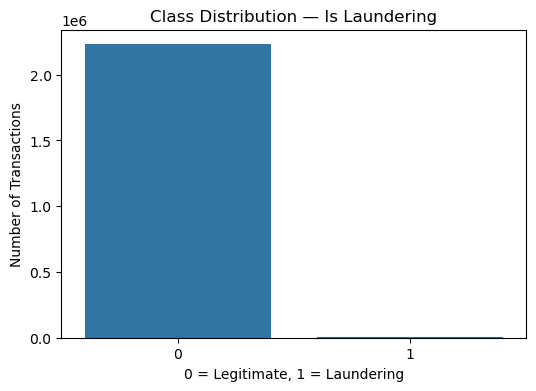

In [13]:
# Class Distribution Analysis

class_counts = sample_df['Is Laundering'].value_counts().sort_index()

class_percent = (
    sample_df['Is Laundering']
    .value_counts(normalize=True)
    .sort_index() * 100
)

class_distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percent
})

print(class_distribution_df)

plt.figure(figsize=(6,4))

sns.countplot(
    x='Is Laundering',
    data=sample_df
)

plt.title('Class Distribution — Is Laundering')
plt.xlabel('0 = Legitimate, 1 = Laundering')
plt.ylabel('Number of Transactions')

plt.savefig(
    'class_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [14]:
# Separate features (X) from the target we want to predict (y)
X = sample_df.drop(columns=['Is Laundering'])
y = sample_df['Is Laundering']

# Split: 80% for training, 20% for testing
# stratify=y makes sure both sets keep the same tiny percentage of laundering cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining set class balance:")
print(y_train.value_counts())

Training set size: (1786301, 16)
Test set size: (446576, 16)

Training set class balance:
Is Laundering
0    1784328
1       1973
Name: count, dtype: int64


In [15]:
scaler = StandardScaler()

# Learn the scaling from the training data only, then apply it to both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. Example of scaled training data:")
print(X_train_scaled[:3])

Scaling complete. Example of scaled training data:
[[-0.47814282  2.74946737 -0.00742841 -0.10664222 -0.0069753  -0.1132131
   0.69122043  0.37515872  0.88064285  0.          0.          1.13881279
  -0.78721931  0.028316   -0.310077    0.12393892]
 [-0.12742824 -0.59670825 -0.00744811 -1.05210946 -0.00699922 -1.05910184
   0.69122043  0.37515872 -1.49045743  0.          0.          1.33382459
   1.1373045  -0.55001716 -0.310077    0.12393892]
 [-0.13345414 -0.596109   -0.00746682  0.83882502 -0.00702195  0.83267565
   0.69122043  0.8520586   0.40642279  0.          0.         -0.61629337
  -1.06215128 -1.35968358 -0.310077    0.12393892]]


In [16]:
# Hybrid Resampling: Undersample THEN SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("Before any resampling:")
print(y_train.value_counts())

# Reduce the legitimate (majority) class to a manageable size
# We keep ALL laundering cases untouched, only reducing the legitimate ones
undersampler = RandomUnderSampler(sampling_strategy={0: 100000}, random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

print("\nAfter undersampling the legitimate class:")
print(pd.Series(y_train_under).value_counts())

# Apply SMOTE to bring laundering cases up to a healthier ratio
# sampling_strategy=0.5 means laundering cases will become 50% of the legitimate count
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_under, y_train_under)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before any resampling:
Is Laundering
0    1784328
1       1973
Name: count, dtype: int64

After undersampling the legitimate class:
Is Laundering
0    100000
1      1973
Name: count, dtype: int64

After SMOTE:
Is Laundering
0    100000
1     50000
Name: count, dtype: int64


In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    'SVM': LinearSVC(random_state=42, max_iter=5000)
}

print("6 models defined:", list(models.keys()))

6 models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network', 'SVM']


In [18]:
trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    model.fit(X_train_smote, y_train_smote)
    elapsed = time.time() - start_time
    trained_models[name] = model
    training_times[name] = elapsed
    print(f"  Finished in {elapsed:.1f} seconds.\n")

print("All 6 models trained successfully.")

Training Logistic Regression...
  Finished in 0.2 seconds.

Training Decision Tree...
  Finished in 2.0 seconds.

Training Random Forest...
  Finished in 8.6 seconds.

Training XGBoost...
  Finished in 0.9 seconds.

Training Neural Network...
  Finished in 295.2 seconds.

Training SVM...
  Finished in 0.4 seconds.

All 6 models trained successfully.


In [19]:
# Initial Model Comparison:
initial_results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    initial_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    })

initial_results_df = pd.DataFrame(initial_results)

initial_results_df = initial_results_df.sort_values(
    'F1',
    ascending=False
)

print(initial_results_df)

                 Model  Accuracy  Precision    Recall        F1
3              XGBoost  0.994167   0.087822  0.456389  0.147300
2        Random Forest  0.986627   0.045613  0.557809  0.084330
1        Decision Tree  0.977184   0.026007  0.539554  0.049622
4       Neural Network  0.934743   0.011892  0.707911  0.023391
0  Logistic Regression  0.903197   0.010110  0.894523  0.019995
5                  SVM  0.900633   0.009895  0.898580  0.019575


In [20]:
# scores for all 6 models

all_predictions = {}
all_scores = {}

for name, model in trained_models.items():
    all_predictions[name] = model.predict(X_test_scaled)
    if hasattr(model, "predict_proba"):
        all_scores[name] = model.predict_proba(X_test_scaled)[:, 1]
    else:
        # LinearSVC has no predict_proba — we use decision_function instead
        all_scores[name] = model.decision_function(X_test_scaled)

print("Predictions and scores ready for all 6 models.")

Predictions and scores ready for all 6 models.


                 Model  Accuracy  Precision    Recall        F1   ROC_AUC  \
3              XGBoost  0.994167   0.087822  0.456389  0.147300  0.970414   
2        Random Forest  0.986627   0.045613  0.557809  0.084330  0.963405   
1        Decision Tree  0.977184   0.026007  0.539554  0.049622  0.758611   
4       Neural Network  0.934743   0.011892  0.707911  0.023391  0.928596   
0  Logistic Regression  0.903197   0.010110  0.894523  0.019995  0.924873   
5                  SVM  0.900633   0.009895  0.898580  0.019575  0.924807   

     PR_AUC  
3  0.232649  
2  0.087285  
1  0.014541  
4  0.016720  
0  0.036019  
5  0.035722  


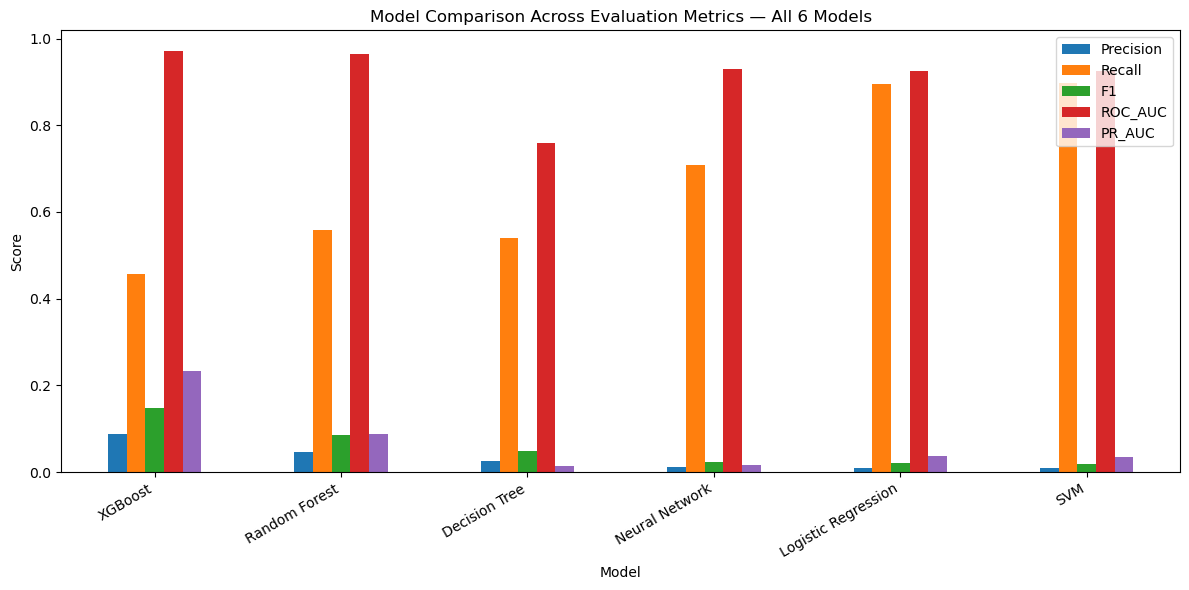

In [21]:
# Main comparison table

final_results = []

for name in trained_models.keys():
    y_pred = all_predictions[name]
    y_score = all_scores[name]

    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_score),
        'PR_AUC': average_precision_score(y_test, y_score)
    })

final_results_df = pd.DataFrame(final_results).sort_values('F1', ascending=False)
print(final_results_df)
final_results_df.to_csv('main_comparison_table.csv', index=False)

# Graph — visual comparison across all metrics
final_results_df.set_index('Model')[['Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']].plot(
    kind='bar', figsize=(12, 6)
)
plt.title('Model Comparison Across Evaluation Metrics — All 6 Models')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('all6_metrics_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()


Logistic Regression Confusion Matrix:
                       Predicted 0  Predicted 1
Actual 0 (Legit)            402905        43178
Actual 1 (Laundering)           52          441

Decision Tree Confusion Matrix:
                       Predicted 0  Predicted 1
Actual 0 (Legit)            436121         9962
Actual 1 (Laundering)          227          266

Random Forest Confusion Matrix:
                       Predicted 0  Predicted 1
Actual 0 (Legit)            440329         5754
Actual 1 (Laundering)          218          275

XGBoost Confusion Matrix:
                       Predicted 0  Predicted 1
Actual 0 (Legit)            443746         2337
Actual 1 (Laundering)          268          225

Neural Network Confusion Matrix:
                       Predicted 0  Predicted 1
Actual 0 (Legit)            417085        28998
Actual 1 (Laundering)          144          349

SVM Confusion Matrix:
                       Predicted 0  Predicted 1
Actual 0 (Legit)            401758        4

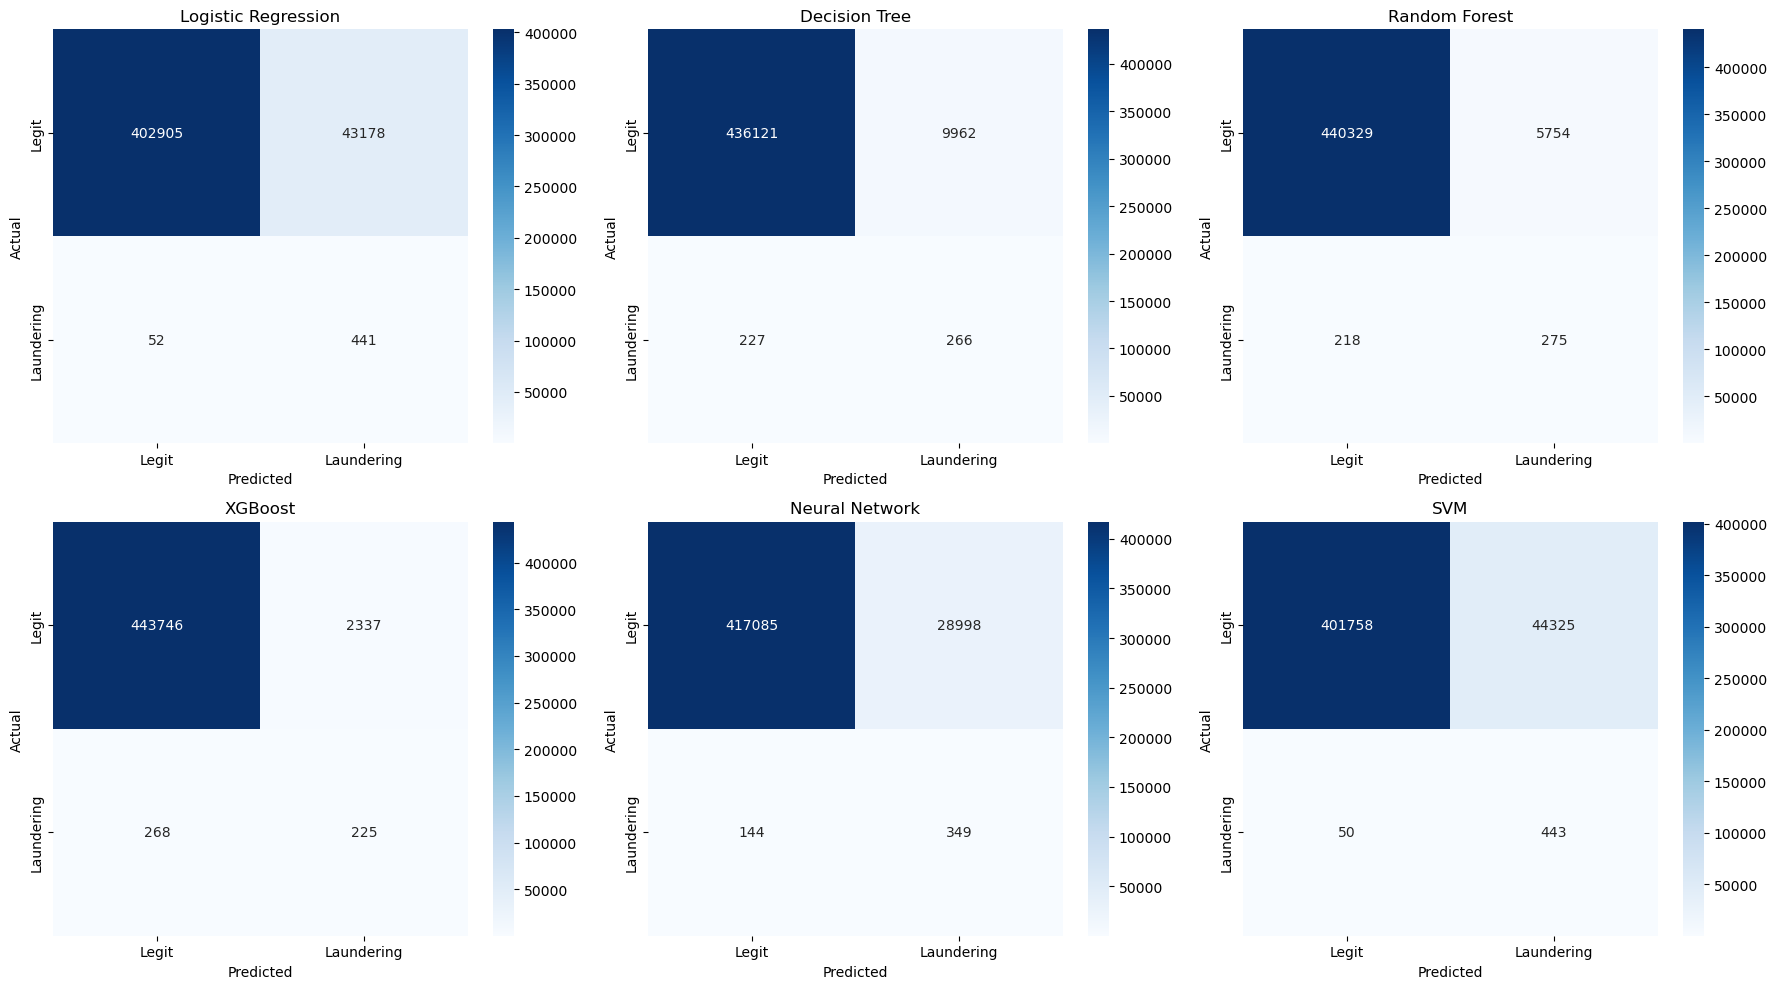

In [22]:
# Confusion matrices

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, name in enumerate(trained_models.keys()):
    cm = confusion_matrix(y_test, all_predictions[name])

    # Print the exact numbers before plotting
    print(f"\n{name} Confusion Matrix:")
    print(pd.DataFrame(cm, index=['Actual 0 (Legit)', 'Actual 1 (Laundering)'],
                        columns=['Predicted 0', 'Predicted 1']))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legit', 'Laundering'], yticklabels=['Legit', 'Laundering'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('all6_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


ROC-AUC Values — All 6 Models
                 Model   ROC_AUC
3              XGBoost  0.970414
2        Random Forest  0.963405
4       Neural Network  0.928596
0  Logistic Regression  0.924873
5                  SVM  0.924807
1        Decision Tree  0.758611


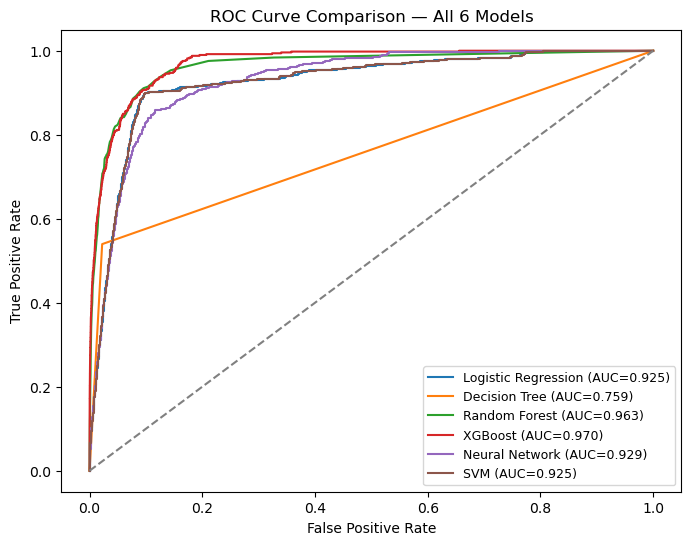

In [23]:
# ROC curves

plt.figure(figsize=(8, 6))
roc_summary = []

for name in trained_models.keys():
    fpr, tpr, _ = roc_curve(y_test, all_scores[name])
    auc_score = roc_auc_score(y_test, all_scores[name])

    roc_summary.append({'Model': name, 'ROC_AUC': auc_score})
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All 6 Models")
plt.legend(fontsize=9)
plt.savefig('all6_roc_curves.png', dpi=300, bbox_inches='tight')

roc_summary_df = pd.DataFrame(roc_summary).sort_values('ROC_AUC', ascending=False)
print("\nROC-AUC Values — All 6 Models")
print(roc_summary_df)
roc_summary_df.to_csv('all6_roc_auc_values.csv', index=False)

plt.show()


Precision-Recall AUC Values — All 6 Models
                 Model    PR_AUC
3              XGBoost  0.232649
2        Random Forest  0.087285
0  Logistic Regression  0.036019
5                  SVM  0.035722
4       Neural Network  0.016720
1        Decision Tree  0.014541


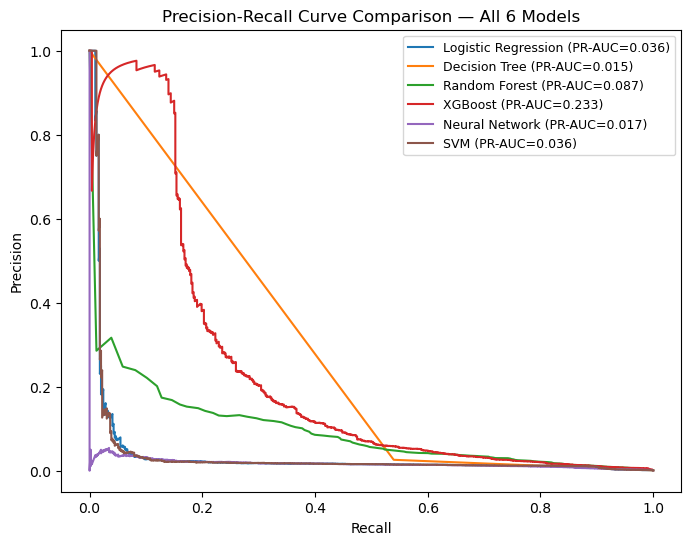

In [24]:
# Precision-Recall curves

plt.figure(figsize=(8, 6))
pr_summary = []

for name in trained_models.keys():
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, all_scores[name])
    pr_auc = average_precision_score(y_test, all_scores[name])

    pr_summary.append({'Model': name, 'PR_AUC': pr_auc})
    plt.plot(rec_vals, prec_vals, label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison — All 6 Models")
plt.legend(fontsize=9)
plt.savefig('all6_pr_curves.png', dpi=300, bbox_inches='tight')

pr_summary_df = pd.DataFrame(pr_summary).sort_values('PR_AUC', ascending=False)
print("\nPrecision-Recall AUC Values — All 6 Models")
print(pr_summary_df)
pr_summary_df.to_csv('all6_pr_auc_values.csv', index=False)

plt.show()


Top 10 Features — Decision Tree
                 Feature  Importance
6         Payment Format    0.610041
2        Amount Received    0.096550
0              From Bank    0.063510
11                   Day    0.050232
1                To Bank    0.029339
12                  Hour    0.028361
8   Receiver_Entity_Type    0.027269
13                Minute    0.023329
15         Same_Currency    0.020188
5       Payment Currency    0.013443


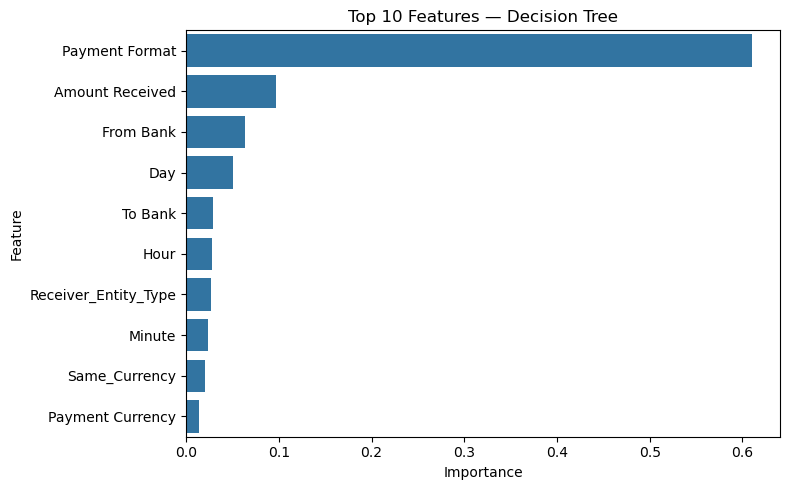


Top 10 Features — Random Forest
                 Feature  Importance
6         Payment Format    0.451317
2        Amount Received    0.098781
4            Amount Paid    0.093501
11                   Day    0.072885
0              From Bank    0.058453
1                To Bank    0.043498
12                  Hour    0.038928
8   Receiver_Entity_Type    0.029502
7     Sender_Entity_Type    0.025474
13                Minute    0.024368


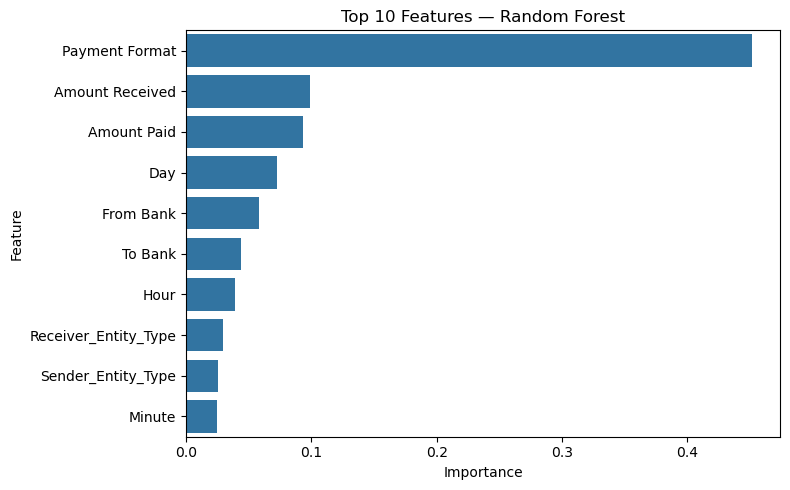


Top 10 Features — XGBoost
                 Feature  Importance
6         Payment Format    0.467867
15         Same_Currency    0.201643
0              From Bank    0.057462
2        Amount Received    0.054188
8   Receiver_Entity_Type    0.045802
11                   Day    0.045684
7     Sender_Entity_Type    0.030809
12                  Hour    0.023871
5       Payment Currency    0.022754
4            Amount Paid    0.021088


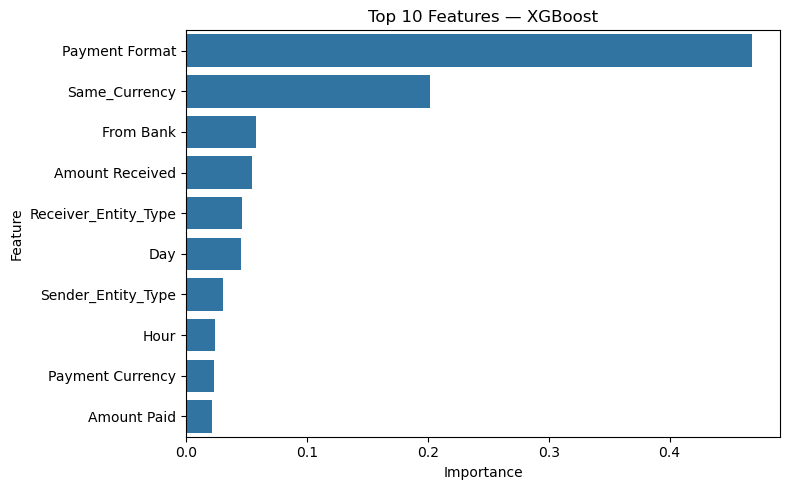


Top 10 Features — Logistic Regression (by |coefficient|)
               Feature  Importance
6       Payment Format    1.831437
15       Same_Currency    1.187729
0            From Bank    0.532428
11                 Day    0.291712
1              To Bank    0.201249
14           Same_Bank    0.198700
12                Hour    0.100936
3   Receiving Currency    0.051587
13              Minute    0.036983
7   Sender_Entity_Type    0.021284


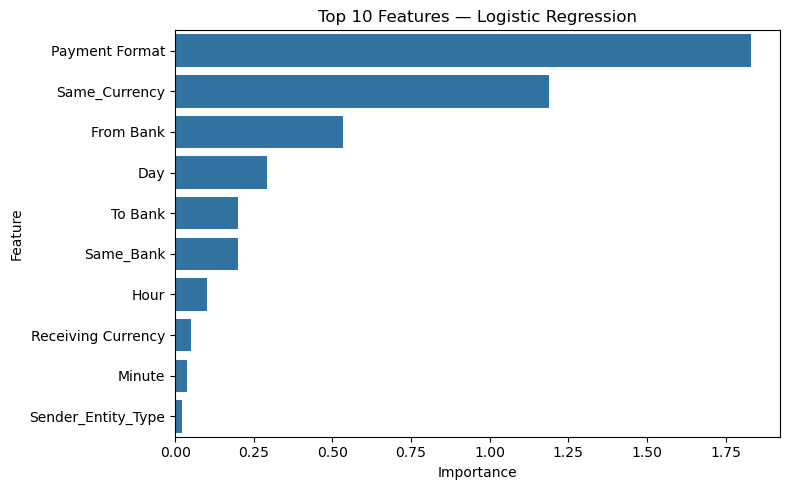


Top 10 Features — SVM (by |coefficient|)
               Feature  Importance
6       Payment Format    0.650928
0            From Bank    0.210618
15       Same_Currency    0.183548
11                 Day    0.084440
14           Same_Bank    0.070146
1              To Bank    0.064638
12                Hour    0.026716
13              Minute    0.011792
3   Receiving Currency    0.011185
7   Sender_Entity_Type    0.004559


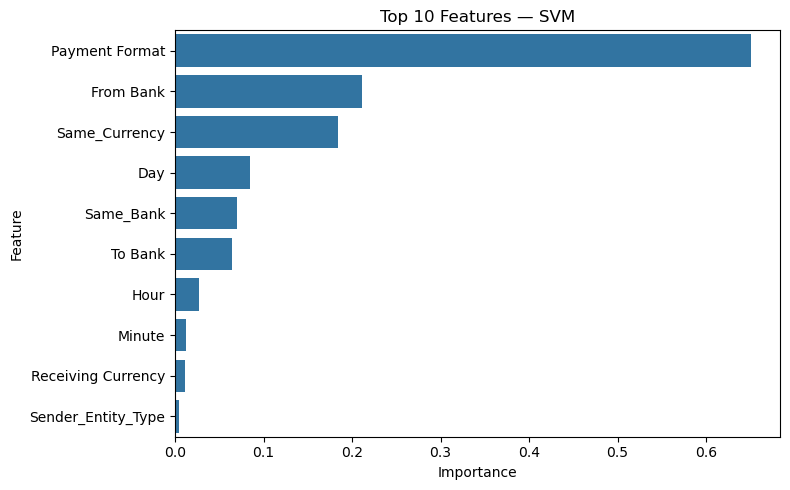


Neural Network: no native feature importance is available for MLPClassifier.


In [25]:
# Feature importance

feature_names = X.columns.tolist()

# Tree-based models — native feature_importances_
for name in ['Decision Tree', 'Random Forest', 'XGBoost']:
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': trained_models[name].feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    print(f"\nTop 10 Features — {name}")
    print(importance_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='Importance', y='Feature')
    plt.title(f'Top 10 Features — {name}')
    plt.tight_layout()
    plt.savefig(f'feature_importance_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Logistic Regression — coefficient magnitude as importance proxy
lr_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': abs(trained_models['Logistic Regression'].coef_[0])
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Features — Logistic Regression (by |coefficient|)")
print(lr_coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=lr_coef_df, x='Importance', y='Feature')
plt.title('Top 10 Features — Logistic Regression')
plt.tight_layout()
plt.savefig('feature_importance_Logistic_Regression.png', dpi=300, bbox_inches='tight')
plt.show()

# SVM (LinearSVC) — same coefficient-based approach
svm_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': abs(trained_models['SVM'].coef_[0])
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Features — SVM (by |coefficient|)")
print(svm_coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=svm_coef_df, x='Importance', y='Feature')
plt.title('Top 10 Features — SVM')
plt.tight_layout()
plt.savefig('feature_importance_SVM.png', dpi=300, bbox_inches='tight')
plt.show()

# Neural Network — no native feature importance available
print("\nNeural Network: no native feature importance is available for MLPClassifier.")

In [26]:
top3 = initial_results_df.head(3)

print(top3)

           Model  Accuracy  Precision    Recall        F1
3        XGBoost  0.994167   0.087822  0.456389  0.147300
2  Random Forest  0.986627   0.045613  0.557809  0.084330
1  Decision Tree  0.977184   0.026007  0.539554  0.049622


In [27]:
# Cross-Validation of Top 3 Models

top_models = {
    'XGBoost': trained_models['XGBoost'],
    'Random Forest': trained_models['Random Forest'],
    'Decision Tree': trained_models['Decision Tree']
}

cv_results = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in top_models.items():

    print(f"\nRunning CV for {name}...")

    scores = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=skf,
        scoring='f1',
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'Mean_F1': scores.mean(),
        'Std_F1': scores.std()
    })

    print(f"Mean F1: {scores.mean():.4f}")
    print(f"Std F1 : {scores.std():.4f}")

cv_results_df = pd.DataFrame(cv_results)

print("\nCross Validation Results")
print(cv_results_df.sort_values('Mean_F1', ascending=False))


Running CV for XGBoost...
Mean F1: 0.9831
Std F1 : 0.0004

Running CV for Random Forest...
Mean F1: 0.9763
Std F1 : 0.0011

Running CV for Decision Tree...
Mean F1: 0.9574
Std F1 : 0.0007

Cross Validation Results
           Model   Mean_F1    Std_F1
0        XGBoost  0.983129  0.000421
1  Random Forest  0.976297  0.001087
2  Decision Tree  0.957426  0.000658


In [28]:
# Hyperparameter Tuning of top 3 models:
# RANDOM FOREST TUNING

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_smote, y_train_smote)

print("Best RF Parameters:")
print(rf_search.best_params_)

best_rf = rf_search.best_estimator_

# XGBOOST TUNING

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),
    param_distributions=xgb_params,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_smote, y_train_smote)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

best_xgb = xgb_search.best_estimator_

# DECISION TREE TUNING

dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train_smote, y_train_smote)

print("Best Decision Tree Parameters:")
print(dt_search.best_params_)

best_dt = dt_search.best_estimator_

Best RF Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best Decision Tree Parameters:
{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'entropy'}


In [29]:
# Train Best Tuned Models

tuned_models = {
    'XGBoost': best_xgb,
    'Random Forest': best_rf,
    'Decision Tree': best_dt
}

tuned_training_times = {}

for name, model in tuned_models.items():

    print(f"Training tuned {name}...")

    start_time = time.time()

    model.fit(X_train_smote, y_train_smote)

    elapsed = time.time() - start_time
    tuned_training_times[name] = elapsed

    print(f"Finished in {elapsed:.2f} seconds.\n")

print("All tuned models trained successfully.")

# Show training times
print("\nTraining Times:")
for name, t in tuned_training_times.items():
    print(f"{name}: {t:.2f} seconds")

Training tuned XGBoost...
Finished in 1.40 seconds.

Training tuned Random Forest...
Finished in 20.96 seconds.

Training tuned Decision Tree...
Finished in 1.98 seconds.

All tuned models trained successfully.

Training Times:
XGBoost: 1.40 seconds
Random Forest: 20.96 seconds
Decision Tree: 1.98 seconds


In [30]:
# Predictions

tuned_predictions = {}
tuned_probabilities = {}

for name, model in tuned_models.items():

    tuned_predictions[name] = model.predict(X_test_scaled)

    tuned_probabilities[name] = model.predict_proba(X_test_scaled)[:,1]

print("Predictions completed.")

Predictions completed.


In [31]:
# Evaluation Metrics

tuned_results = []

for name in tuned_models.keys():

    y_pred = tuned_predictions[name]
    y_prob = tuned_probabilities[name]

    tuned_results.append({

        'Model': name,

        'Accuracy':
            accuracy_score(y_test,y_pred),

        'Precision':
            precision_score(y_test,y_pred,zero_division=0),

        'Recall':
            recall_score(y_test,y_pred,zero_division=0),

        'F1':
            f1_score(y_test,y_pred,zero_division=0),

        'ROC_AUC':
            roc_auc_score(y_test,y_prob),

        'PR_AUC':
            average_precision_score(y_test,y_prob)

    })

tuned_results_df = pd.DataFrame(tuned_results)

print(tuned_results_df.sort_values('F1',ascending=False))

           Model  Accuracy  Precision    Recall        F1   ROC_AUC    PR_AUC
0        XGBoost  0.989742   0.056038  0.523327  0.101236  0.971387  0.225263
1  Random Forest  0.980610   0.036023  0.643002  0.068223  0.966517  0.107551
2  Decision Tree  0.973646   0.025261  0.608519  0.048508  0.797631  0.017315


In [32]:
# Cross Validation of Tuned Models

cv_results_tuned = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in tuned_models.items():

    scores = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=skf,
        scoring='f1',
        n_jobs=-1
    )

    cv_results_tuned.append({
        'Model': name,
        'Mean_F1': scores.mean(),
        'Std_F1': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results_tuned)

print(cv_results_df)

           Model   Mean_F1    Std_F1
0        XGBoost  0.977098  0.001142
1  Random Forest  0.971664  0.000940
2  Decision Tree  0.957552  0.000787


In [33]:
# Classification reports

for name in tuned_models.keys():

    print(f"\n{'='*60}")
    print(f"Classification Report — {name}")
    print(f"{'='*60}")

    print(
        classification_report(
            y_test,
            tuned_predictions[name],
            target_names=['Legitimate', 'Laundering']
        )
    )


Classification Report — XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99    446083
  Laundering       0.06      0.52      0.10       493

    accuracy                           0.99    446576
   macro avg       0.53      0.76      0.55    446576
weighted avg       1.00      0.99      0.99    446576


Classification Report — Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    446083
  Laundering       0.04      0.64      0.07       493

    accuracy                           0.98    446576
   macro avg       0.52      0.81      0.53    446576
weighted avg       1.00      0.98      0.99    446576


Classification Report — Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99    446083
  Laundering       0.03      0.61      0.05       493

    accuracy                           0.97    446576
   macro avg     


XGBoost Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0       441737         4346
Actual 1          235          258

Random Forest Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0       437600         8483
Actual 1          176          317

Decision Tree Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0       434507        11576
Actual 1          193          300


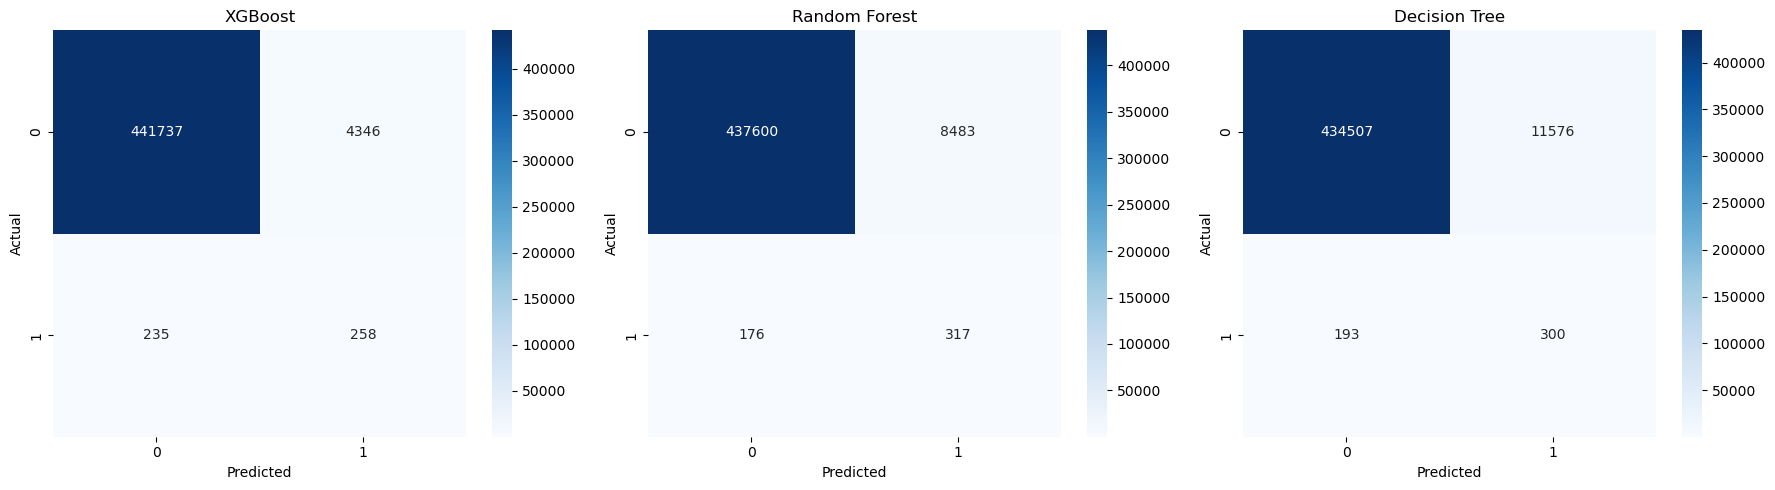

In [34]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for idx, name in enumerate(tuned_models.keys()):

    cm = confusion_matrix(
        y_test,
        tuned_predictions[name]
    )

    print(f"\n{name} Confusion Matrix:")
    print(
        pd.DataFrame(
            cm,
            index=['Actual 0', 'Actual 1'],
            columns=['Predicted 0', 'Predicted 1']
        )
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx]
    )

    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(
    "tuned_confusion_matrices.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


ROC-AUC Values


,Model,ROC_AUC
0,XGBoost,0.971387
1,Random Forest,0.966517
2,Decision Tree,0.797631


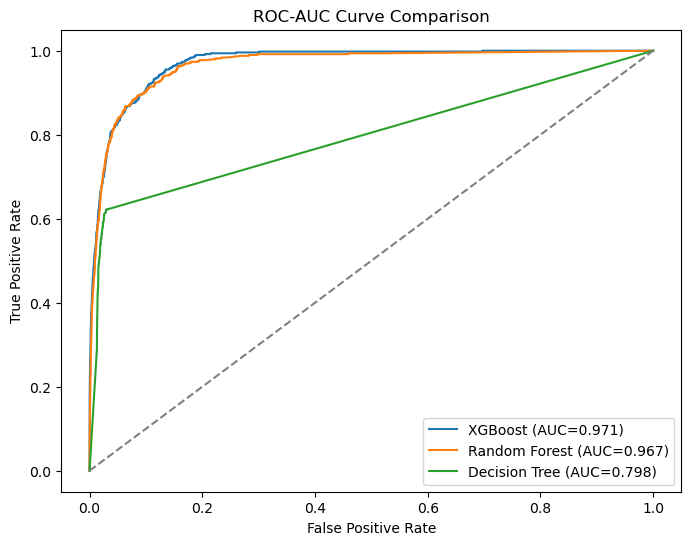

In [35]:
# ROC Curves
plt.figure(figsize=(8,6))

roc_summary = []

for name in tuned_models.keys():

    fpr, tpr, _ = roc_curve(
        y_test,
        tuned_probabilities[name]
    )

    auc_score = roc_auc_score(
        y_test,
        tuned_probabilities[name]
    )

    roc_summary.append({
        'Model': name,
        'ROC_AUC': auc_score
    })

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()

plt.savefig(
    "tuned_roc_curves.png",
    dpi=300,
    bbox_inches='tight'
)

roc_summary_df = pd.DataFrame(roc_summary)
print("\nROC-AUC Values")
display(roc_summary_df.sort_values('ROC_AUC', ascending=False))

plt.show()


Precision-Recall AUC Values


,Model,PR_AUC
0,XGBoost,0.225263
1,Random Forest,0.107551
2,Decision Tree,0.017315


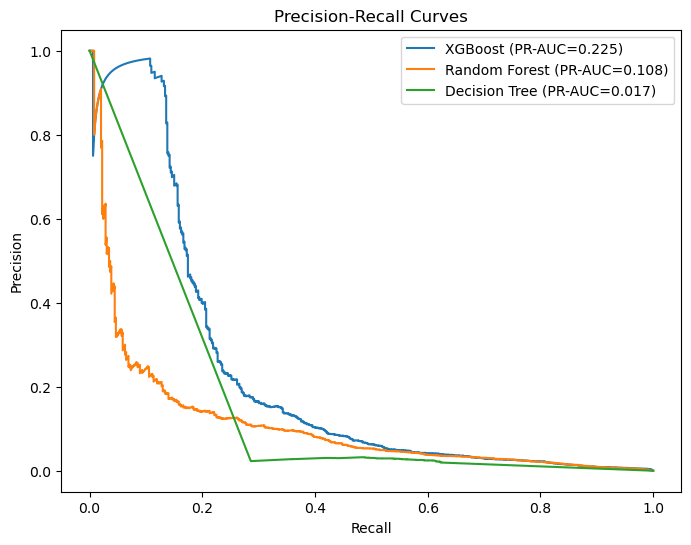

In [36]:
# Precision Recall Curves
plt.figure(figsize=(8,6))

pr_summary = []

for name in tuned_models.keys():

    precision_vals, recall_vals, _ = precision_recall_curve(
        y_test,
        tuned_probabilities[name]
    )

    pr_auc = average_precision_score(
        y_test,
        tuned_probabilities[name]
    )

    pr_summary.append({
        'Model': name,
        'PR_AUC': pr_auc
    })

    plt.plot(
        recall_vals,
        precision_vals,
        label=f"{name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()

plt.savefig(
    "tuned_pr_curves.png",
    dpi=300,
    bbox_inches='tight'
)

pr_summary_df = pd.DataFrame(pr_summary)
print("\nPrecision-Recall AUC Values")
display(pr_summary_df.sort_values('PR_AUC', ascending=False))

plt.show()

In [37]:
# Comparative Metrics Table

print(
    tuned_results_df.sort_values(
        'F1',
        ascending=False
    )
)

tuned_results_df.to_csv(
    'tuned_model_comparison.csv',
    index=False
)

           Model  Accuracy  Precision    Recall        F1   ROC_AUC    PR_AUC
0        XGBoost  0.989742   0.056038  0.523327  0.101236  0.971387  0.225263
1  Random Forest  0.980610   0.036023  0.643002  0.068223  0.966517  0.107551
2  Decision Tree  0.973646   0.025261  0.608519  0.048508  0.797631  0.017315


In [38]:
# Ranking Models

ranking = tuned_results_df.sort_values(
    'F1',
    ascending=False
).reset_index(drop=True)

print(ranking)

best_model_name = ranking.iloc[0]['Model']

print(
    f"\nBest Model Overall: {best_model_name}"
)

           Model  Accuracy  Precision    Recall        F1   ROC_AUC    PR_AUC
0        XGBoost  0.989742   0.056038  0.523327  0.101236  0.971387  0.225263
1  Random Forest  0.980610   0.036023  0.643002  0.068223  0.966517  0.107551
2  Decision Tree  0.973646   0.025261  0.608519  0.048508  0.797631  0.017315

Best Model Overall: XGBoost



Top 10 Features — Random Forest


,Feature,Importance
6,Payment Format,0.479481
4,Amount Paid,0.097741
2,Amount Received,0.091542
11,Day,0.071975
0,From Bank,0.054945
1,To Bank,0.040303
12,Hour,0.032098
8,Receiver_Entity_Type,0.028368
7,Sender_Entity_Type,0.023825
5,Payment Currency,0.021057


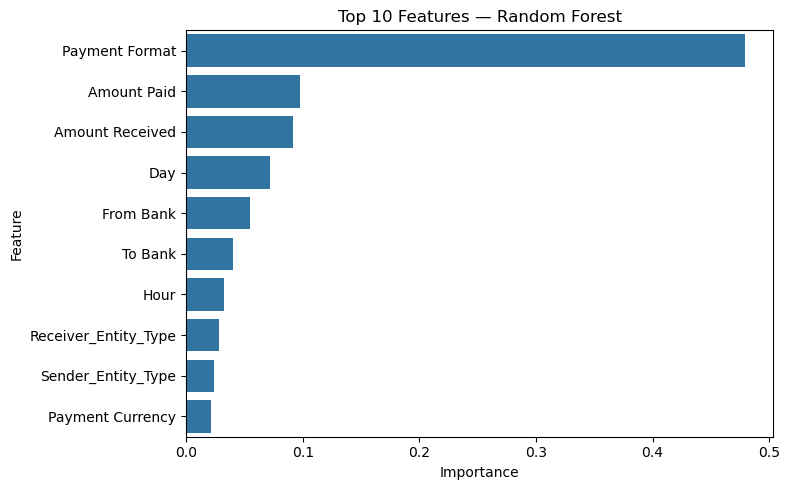


Top 10 Features — Decision Tree


,Feature,Importance
6,Payment Format,0.555564
0,From Bank,0.115149
2,Amount Received,0.087894
11,Day,0.060187
1,To Bank,0.027350
12,Hour,0.025780
8,Receiver_Entity_Type,0.025026
15,Same_Currency,0.020061
13,Minute,0.019792
4,Amount Paid,0.017784


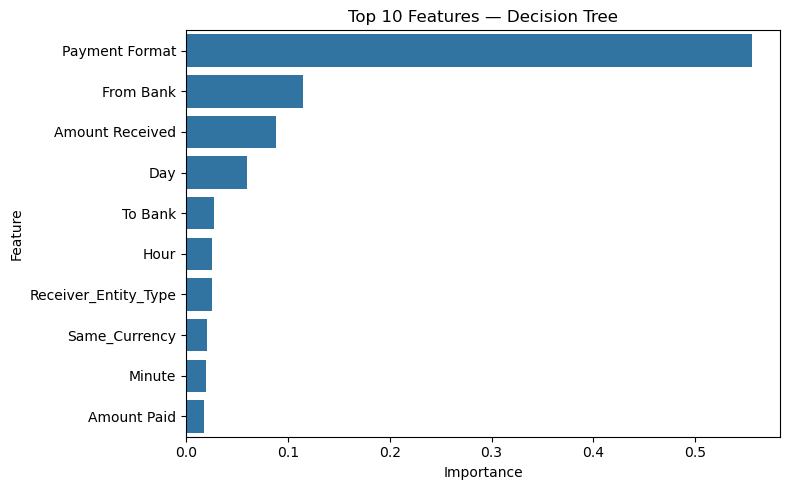


Top 10 Features — XGBoost


,Feature,Importance
6,Payment Format,0.418665
15,Same_Currency,0.128166
2,Amount Received,0.065942
0,From Bank,0.063463
8,Receiver_Entity_Type,0.057097
11,Day,0.056834
4,Amount Paid,0.053691
7,Sender_Entity_Type,0.044117
12,Hour,0.032236
14,Same_Bank,0.022890


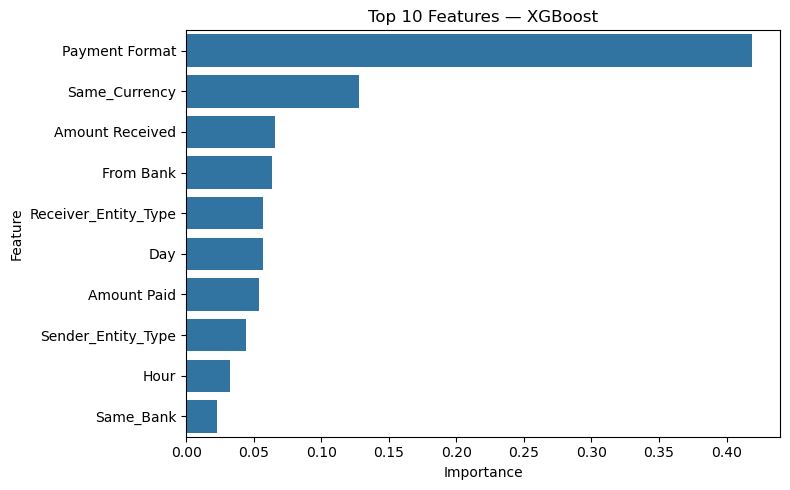

In [39]:
# Feature Importance
feature_names = X.columns.tolist()

tree_models = {
    'Random Forest': best_rf,
    'Decision Tree': best_dt,
    'XGBoost': best_xgb
}

for name, model in tree_models.items():

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        'Importance',
        ascending=False
    ).head(10)

    print(f"\nTop 10 Features — {name}")
    display(importance_df)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=importance_df,
        x='Importance',
        y='Feature'
    )

    plt.title(
        f"Top 10 Features — {name}"
    )

    plt.tight_layout()
    plt.show()

                 Model  Training Time (Seconds)
0  Logistic Regression                 0.229158
5                  SVM                 0.370255
3              XGBoost                 0.913680
1        Decision Tree                 1.976527
2        Random Forest                 8.576571
4       Neural Network               295.154981


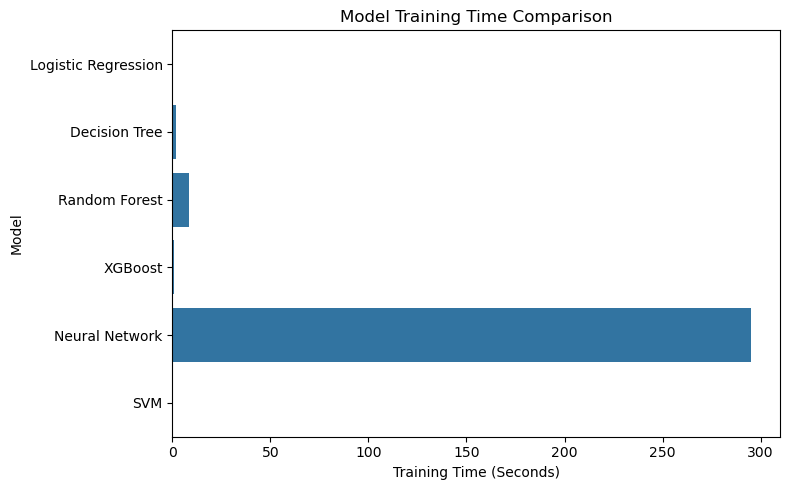

In [40]:
# Training Time Analysis

training_time_df = pd.DataFrame({

    'Model':
        list(training_times.keys()),

    'Training Time (Seconds)':
        list(training_times.values())

})

print(
    training_time_df.sort_values(
        'Training Time (Seconds)'
    )
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=training_time_df,
    x='Training Time (Seconds)',
    y='Model'
)

plt.title(
    'Model Training Time Comparison'
)

plt.tight_layout()
plt.show()

In [41]:
# Overfitting Analysis

overfitting_results = []

for name, model in tuned_models.items():

    train_pred = model.predict(
        X_train_smote
    )

    train_acc = accuracy_score(
        y_train_smote,
        train_pred
    )

    test_acc = accuracy_score(
        y_test,
        tuned_predictions[name]
    )

    overfitting_results.append({

        'Model': name,

        'Train Accuracy':
            train_acc,

        'Test Accuracy':
            test_acc,

        'Gap':
            train_acc - test_acc
    })

overfitting_df = pd.DataFrame(
    overfitting_results
)

print(overfitting_df)

           Model  Train Accuracy  Test Accuracy       Gap
0        XGBoost        0.986800       0.989742 -0.002942
1  Random Forest        0.992067       0.980610  0.011456
2  Decision Tree        0.989913       0.973646  0.016267


In [42]:
# Final Results Display

print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
display(tuned_results_df.sort_values('F1', ascending=False))

print("\n" + "="*70)
print("CROSS VALIDATION RESULTS")
print("="*70)
display(cv_results_df)

print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)
display(overfitting_df)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.989742,0.056038,0.523327,0.101236,0.971387,0.225263
1,Random Forest,0.980610,0.036023,0.643002,0.068223,0.966517,0.107551
2,Decision Tree,0.973646,0.025261,0.608519,0.048508,0.797631,0.017315



CROSS VALIDATION RESULTS


,Model,Mean_F1,Std_F1
0,XGBoost,0.977098,0.001142
1,Random Forest,0.971664,0.000940
2,Decision Tree,0.957552,0.000787



OVERFITTING ANALYSIS


,Model,Train Accuracy,Test Accuracy,Gap
0,XGBoost,0.986800,0.989742,-0.002942
1,Random Forest,0.992067,0.980610,0.011456
2,Decision Tree,0.989913,0.973646,0.016267


In [43]:
# FINAL MODEL RANKING

final_ranking = tuned_results_df.sort_values(
    'F1',
    ascending=False
).reset_index(drop=True)

print("="*70)
print("FINAL MODEL RANKING")
print("="*70)

display(final_ranking)

print(f"\nBest Model: {final_ranking.iloc[0]['Model']}")

FINAL MODEL RANKING


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.989742,0.056038,0.523327,0.101236,0.971387,0.225263
1,Random Forest,0.980610,0.036023,0.643002,0.068223,0.966517,0.107551
2,Decision Tree,0.973646,0.025261,0.608519,0.048508,0.797631,0.017315



Best Model: XGBoost


In [44]:
#Export Results

tuned_results_df.to_csv(
    'final_model_comparison.csv',
    index=False
)

cv_results_df.to_csv(
    'cross_validation_results.csv',
    index=False
)

overfitting_df.to_csv(
    'overfitting_analysis.csv',
    index=False
)

print(
    "All dissertation result tables exported successfully."
)

All dissertation result tables exported successfully.
